# Segmentation Demo: „Welche Pixel gehören zu welchem Objekt?“

Bei **Segmentierung** geht es nicht nur darum, *dass* ein Objekt da ist und *wo* es ist,
sondern **welche Pixel** zu diesem Objekt gehören.

Wir gehen wieder Schritt für Schritt vor:
1) Bild laden und anschauen
2) YOLO-Segmentierungsmodell laden
3) Inferenz ausführen
4) Ergebnis untersuchen:
   - Gibt es Masken? Wie viele?
   - Welche Shapes haben die Masken?
   - Wie sehen Boxes + Klassen pro Instanz aus?
5) Ergebnisse visualisieren.

## Für Colab...

In [ ]:
# relevante Packages laden...
!pip -q install ultralytics opencv-python matplotlib numpy

# drive mounten, damit wir auf die Bilder/Videos zugreifen können
from google.colab import drive
drive.mount('/content/drive')

## Testbild laden: wieder unser Katzenbild

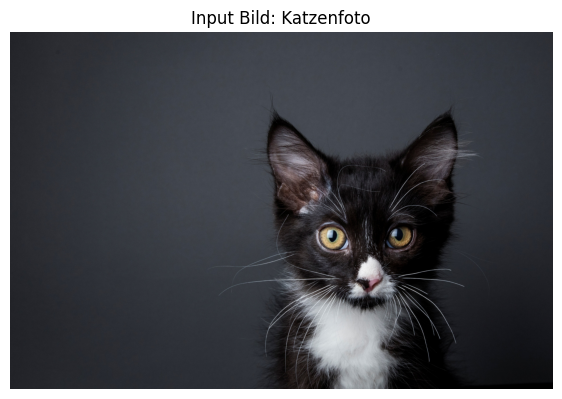

Image shape (H,W,C): (2475, 3758, 3)


In [ ]:
import cv2
import matplotlib.pyplot as plt

# für Colab: 
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/cats/cat1.jpg"
img_path = "/home/u88m52/projects/DIH-CV/images/cats/cat1.jpg"
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(7,5))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Input Bild: Katzenfoto")
plt.show()

print("Image shape (H,W,C):", img_bgr.shape)

## Segmentierungsmodell laden

Wir haben wieder unser bekanntes Katzenfotos geladen, und uns erneut die Dimensionen 
ausgeben lassen, damit wir uns wieder richtig daran erinnern können.

Als nächstes laden wir ein YOLO-Segmentierungsmodell und sehen uns die Architektur ein
wenig genauer an:

In [2]:
from ultralytics import YOLO

seg_model = YOLO("yolo11s-seg.pt")  # Segmentierungsmodell
seg_model

YOLO(
  (model): SegmentationModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(96, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(128, eps=0.001, momentum=0.03, affine=True, track_run

## Inferenz mit dem Segmentierungsmodell

Das Modell ist wieder ähnlich komplex wie das Detektionsmodell, mit 23 Layer-Blöcken.
Sehen wir uns nun an, welches Resultat das Modell für unser Katzenfoto als Input
zurückgibt:

In [4]:
results = seg_model.predict(img_path, conf=0.25, verbose=False)

print("Typ:", type(results))
print("Anzahl Results:", len(results))
print("Typ eines Elements:", type(results[0]))
print(results[0])

Typ: <class 'list'>
Anzahl Results: 1
Typ eines Elements: <class 'ultralytics.engine.results.Results'>
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 

Der Output dieses Modells ist nun schon sehr spannend: wir haben wieder ein Attribut 
`boxes` (genau wie schon im Detektionsmodell), das die Bounding Boxes der erkannten
Objekte enthält, aber nun zusätzlich auch ein `masks` Attribut.

Sehen wir uns das genauer an:

In [ ]:
r0 = results[0]

if r0.boxes is not None:
    print("Anzahl Boxes:", len(r0.boxes))
    print("boxes.xyxy shape:", r0.boxes.xyxy.shape)

if r0.masks is not None:
    print("masks.data shape:", r0.masks.data.shape)

Hat boxes? True
Hat masks? True
Anzahl Boxes: 1
boxes.xyxy shape: torch.Size([1, 4])
masks.data shape: torch.Size([1, 448, 640])


Wir haben jetzt die grundlegende Struktur gesehen:
- `boxes` enthält (wie bei Detection) die Bounding Box Informationen der einzelnen
  Detektionen
- `masks` enthält die segmentierten Pixelmasken

Als nächstes visualisieren wir das Ergebnis direkt:
Ultralytics kann Masken + Boxes + Labels wieder automatisch ins Bild rendern (`result.plot()`).

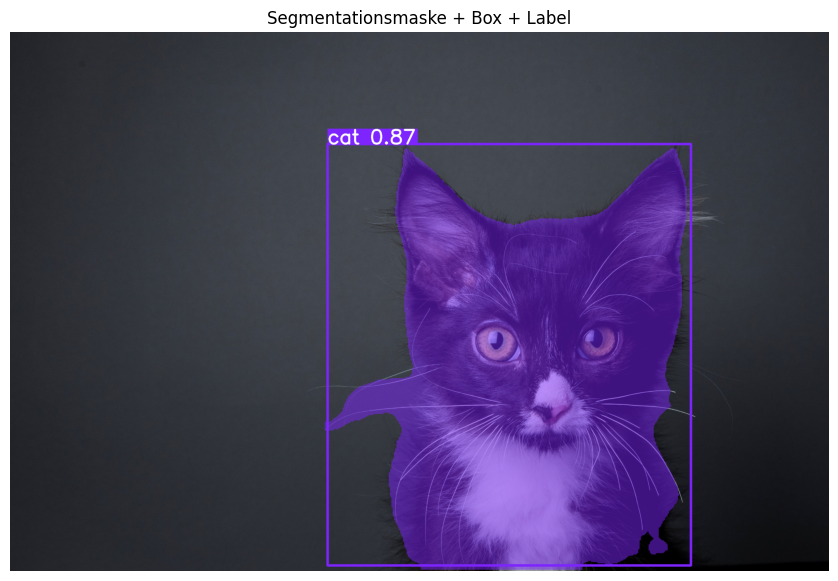

In [8]:
annotated_bgr = r0.plot()  # Masken + Boxen + Labels
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Segmentationsmaske + Box + Label")
plt.show()


Wir sehen jetzt die Masken „über“ dem Bild – das macht Segmentierung sehr anschaulich. 
Zusätzlich werden wieder die Bounding Box, die Klasse, und die dazugehörige Konfidenz
geplottet.

Die Informationen können wir natürlich auch ohne Visualisierung ausgeben:

In [9]:
if r0.boxes is None or len(r0.boxes) == 0:
    print("Keine Instanzen erkannt (boxes leer).")
else:
    n_show = min(5, len(r0.boxes))
    for j in range(n_show):
        cls_id = int(r0.boxes.cls[j])
        name = r0.names[cls_id]
        conf = float(r0.boxes.conf[j])
        xyxy = r0.boxes.xyxy[j].cpu().numpy()
        print(f"{j:02d} | {name:<18} conf={conf:.3f} | xyxy={xyxy}")

    if r0.masks is not None:
        print("\nAnzahl Masken:", r0.masks.data.shape[0])

00 | cat                conf=0.868 | xyxy=[     1457.6      514.55      3124.6      2449.1]

Anzahl Masken: 1


Wir haben jetzt pro Instanz Klasse, Konfidenz und Box gesehen.

Als nächstes greifen wir eine einzelne Maske heraus (z.B. Instanz 0),
wandeln sie in eine Binärmaske um und visualisieren:

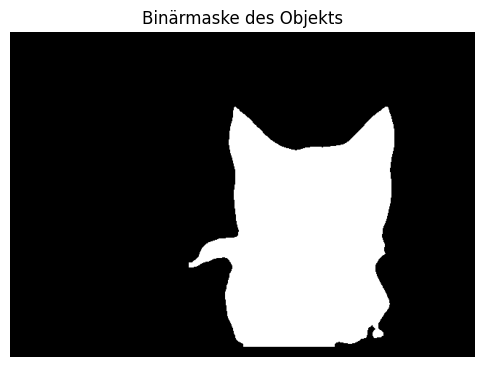

Masken-Daten Shape (N,H,W): torch.Size([1, 448, 640])
Dimensionen des originalen Inputbilds: (2475, 3758)
Dimensionen des skalierten Inputbilds: torch.Size([1, 448, 640])


In [18]:
import numpy as np

m0 = r0.masks.data[0].cpu().numpy()
bin0 = (m0 > 0.5).astype(np.uint8)

plt.figure(figsize=(6,5))
plt.imshow(bin0, cmap="gray")
plt.axis("off")
plt.title("Binärmaske des Objekts")
plt.show()

print("Masken-Daten Shape (N,H,W):", r0.masks.data.shape)
print("Dimensionen des originalen Inputbilds:", r0.masks.orig_shape)
print("Dimensionen des skalierten Inputbilds:", r0.masks.shape)


Wir haben uns jetzt zusätzlich die Shape der Maske ausgeben lassen und sehen: die Maske
hat die gleiche Größe, wie eine 'herunterskalierte' Version des Originalbildes. 

In YOLO-Modellen wird ein Inputbild normalerweise herunterskaliert (die längere Kante
hat dabei per Default 640px), und die Masken in der Segmentierung beziehen sich dann auf
dieses Format. Das macht es möglich, die Masken mehrerer unterschiedlicher Objekte am
Bild dennoch im `mask` Attribut zu sammeln.

Sehen wir uns das für Multi-Objekt Bilder genauer an:

Masken-Daten Shape (N,H,W): torch.Size([2, 448, 640])
Dimensionen des originalen Inputbilds: (2000, 3006)
Dimensionen des skalierten Inputbilds: torch.Size([2, 448, 640])


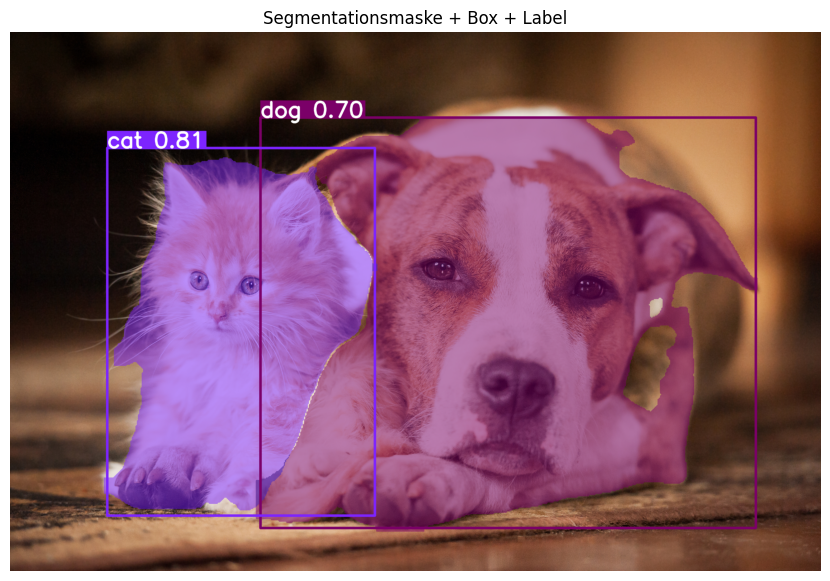

In [ ]:
# für Colab: 
# img_path = "/content/drive/MyDrive/DIH-CV-main/images/multi-object/cat_dog.png"

img_path = "/home/u88m52/projects/DIH-CV/images/multi-object/cat_dog.png"

results = seg_model.predict(img_path, conf=0.25, verbose=False)
r0 = results[0]

print("Masken-Daten Shape (N,H,W):", r0.masks.data.shape)
print("Dimensionen des originalen Inputbilds:", r0.masks.orig_shape)
print("Dimensionen des skalierten Inputbilds:", r0.masks.shape)

annotated_bgr = r0.plot()  # Masken + Boxen + Labels
annotated_rgb = cv2.cvtColor(annotated_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,7))
plt.imshow(annotated_rgb)
plt.axis("off")
plt.title("Segmentationsmaske + Box + Label")
plt.show()

Der Output hat sich wie erwartet verändert: wir haben nun zwei Masken bekommen, eine
für jedes Objekt am Bild.

Interessanterweise ist nun die Konfidenz für die Erkennung der Katze deutlich höher, als
sie beim Detektionsmodell zuvor war - der Beweis dafür, dass es sich hier um eine 
Detektion mit einem anderen Modell handelt. Die Modelle könnten sich nun bzgl. der 
Trainingsdaten unterscheiden (wie z.B. beim Klassifikations- und Detektionsmodell), oder
im Training selbst (gleiche Klassen, aber unterschiedliches Trainingsschema).

Um den Unterschied zu erkennen, sehen wir uns genauer an, welche Klassen dieses Modell
nun erkennen kann:

In [23]:
seg_class_names = seg_model.names

print("Anzahl Klassen:", len(seg_class_names))
print("Erste 10 Klassen:")
list(seg_class_names.items())

Anzahl Klassen: 80
Erste 10 Klassen:


[(0, 'person'),
 (1, 'bicycle'),
 (2, 'car'),
 (3, 'motorcycle'),
 (4, 'airplane'),
 (5, 'bus'),
 (6, 'train'),
 (7, 'truck'),
 (8, 'boat'),
 (9, 'traffic light'),
 (10, 'fire hydrant'),
 (11, 'stop sign'),
 (12, 'parking meter'),
 (13, 'bench'),
 (14, 'bird'),
 (15, 'cat'),
 (16, 'dog'),
 (17, 'horse'),
 (18, 'sheep'),
 (19, 'cow'),
 (20, 'elephant'),
 (21, 'bear'),
 (22, 'zebra'),
 (23, 'giraffe'),
 (24, 'backpack'),
 (25, 'umbrella'),
 (26, 'handbag'),
 (27, 'tie'),
 (28, 'suitcase'),
 (29, 'frisbee'),
 (30, 'skis'),
 (31, 'snowboard'),
 (32, 'sports ball'),
 (33, 'kite'),
 (34, 'baseball bat'),
 (35, 'baseball glove'),
 (36, 'skateboard'),
 (37, 'surfboard'),
 (38, 'tennis racket'),
 (39, 'bottle'),
 (40, 'wine glass'),
 (41, 'cup'),
 (42, 'fork'),
 (43, 'knife'),
 (44, 'spoon'),
 (45, 'bowl'),
 (46, 'banana'),
 (47, 'apple'),
 (48, 'sandwich'),
 (49, 'orange'),
 (50, 'broccoli'),
 (51, 'carrot'),
 (52, 'hot dog'),
 (53, 'pizza'),
 (54, 'donut'),
 (55, 'cake'),
 (56, 'chair'),
 (57

Wie wir sehen, wurde dieses Modell auf den gleichen Daten trainiert, wie das Detektionsmodell
(um genau zu sein, am [COCO-Datensatz](https://docs.ultralytics.com/datasets/detect/coco/#key-features)).
Es handelt sich aber um Modelle mit unterschiedlicher Architektur und unterschiedlichen
Trainingsschemata, daher die unterschiedliche Konfidenz in der Prädiktion gewisser
Klassen (in unserem Fall, der Katze).

Unter Umständen kann es interessant sein, die Liste der Objektklassen, auf die das Modell
trainiert wurde, gezielt abzusuchen (um bspw. zu sehen, ob eine Klasse für `person` 
enthalten ist, oder nicht).

Sehen wir uns an, wie das aussehen kann:

In [24]:
targets = ["person", "dog", "cat", "tumor"]

for t in targets:
    found = [k for k, v in seg_class_names.items() if v == t]
    print(f"{t:<10} →", f"gefunden (ID(s): {found})" if found else "NICHT im Modell")

person     → gefunden (ID(s): [0])
dog        → gefunden (ID(s): [16])
cat        → gefunden (ID(s): [15])
tumor      → NICHT im Modell


## Zusammenfassend...

Damit haben wir die Kernbotschaft der Segmentierung-Demo:
- Segmentierung liefert **pixelgenaue Masken** statt nur Boxen
- Pro Instanz bekommen wir Klasse, Konfidenz, Box und Maske
- Das Modell kann nur Klassen segmentieren, die es im Training gelernt hat

Wir können auch hier wieder den Konfidenz-Threshold abändern - das bleibt den Kursteilnehmern
in einem Selbstversuch überlassen.

In einer nächsten Demo sehen wir uns nun ein völlig anderes Topic an: **Pose Estimation**.